In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv(r"C:\Users\krish\Downloads\archive\Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Shape:", df.shape)

Number of rows: 768
Number of columns: 7
Shape: (768, 7)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [8]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [9]:
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 27


In [11]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [12]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [14]:
print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [15]:
df["Region"] = df["Region"].str.strip()
df["Area"] = df["Area"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()

In [16]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Date"].head()

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]

In [17]:
df.dtypes

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                                  str
dtype: object

In [18]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [19]:
df = df.dropna().reset_index(drop=True)

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (740, 7)


In [20]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [21]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

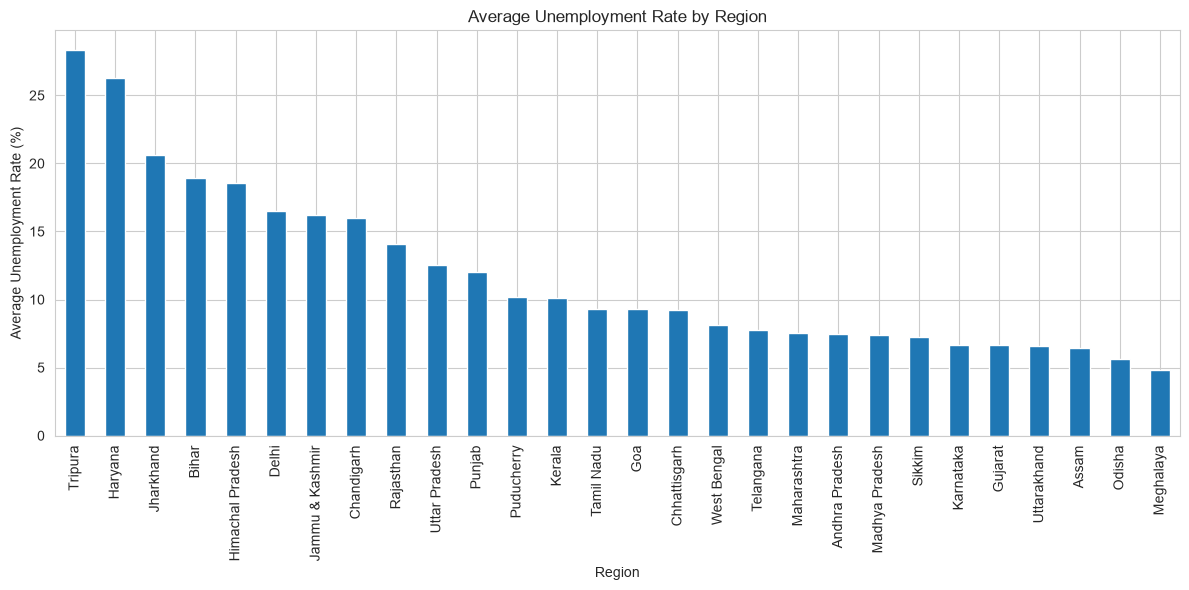

In [22]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [23]:
print(
    "Observation: The chart shows the average unemployment rate "
    "across different regions in India."
)

Observation: The chart shows the average unemployment rate across different regions in India.


In [24]:
monthly_avg = (
    df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"]
    .mean()
)

monthly_avg

Date
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

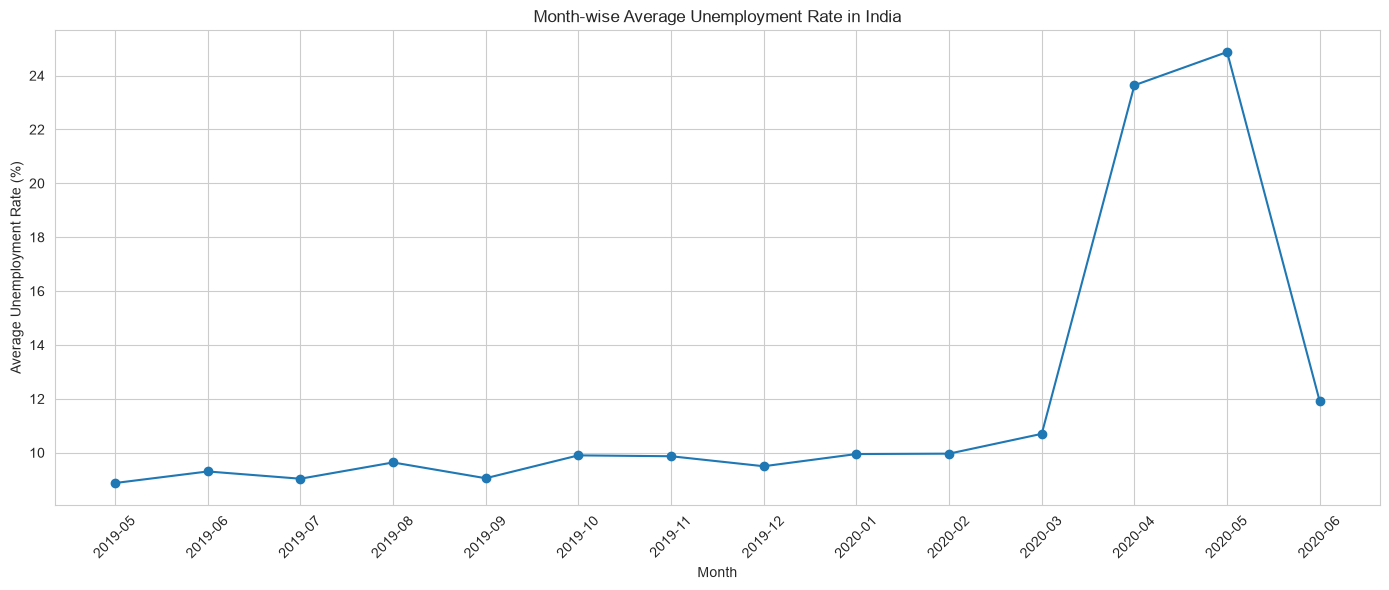

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_avg.index.astype(str),
    monthly_avg.values,
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
print(
    "Observation: The month-wise trend shows how India's average "
    "unemployment rate changed over time."
)

Observation: The month-wise trend shows how India's average unemployment rate changed over time.


In [27]:
top_regions = region_avg.head(3).index.tolist()

top_regions

['Tripura', 'Haryana', 'Jharkhand']

In [28]:
top_region_data = df[df["Region"].isin(top_regions)]

top_region_monthly = (
    top_region_data
    .groupby(["Date", "Region"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

top_region_monthly.head()

,Date,Region,Estimated Unemployment Rate (%)
0,2019-05-31,Haryana,19.605
1,2019-05-31,Jharkhand,12.170
2,2019-05-31,Tripura,31.970
3,2019-06-30,Haryana,21.750
4,2019-06-30,Jharkhand,14.485


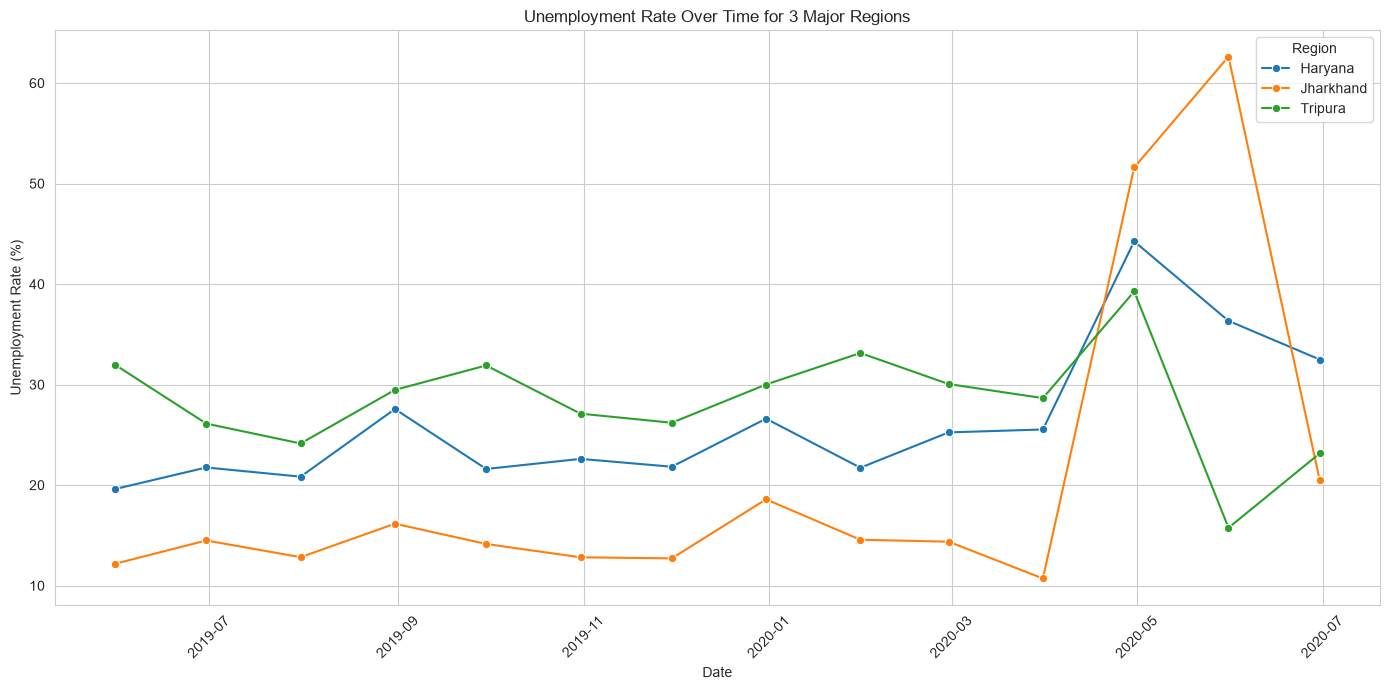

In [29]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=top_region_monthly,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time for 3 Major Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
print(
    "Observation: The time-series chart compares unemployment trends "
    "for three major regions and shows how their unemployment rates "
    "changed over time."
)

Observation: The time-series chart compares unemployment trends for three major regions and shows how their unemployment rates changed over time.


In [31]:
top_10_regions = region_avg.head(10)

top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

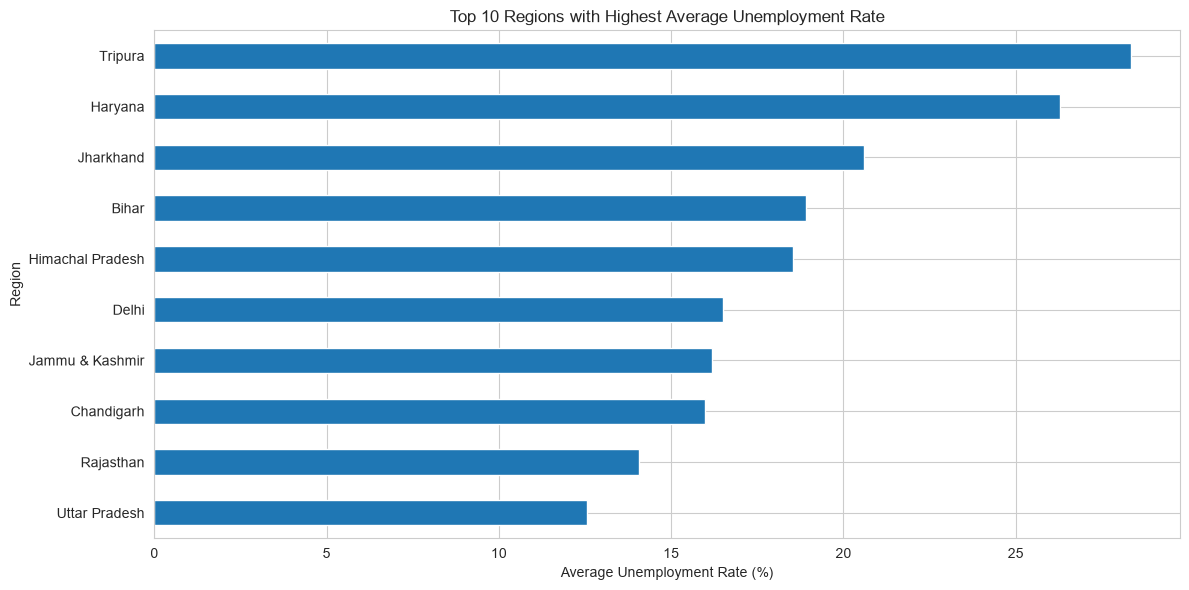

In [32]:
plt.figure(figsize=(12, 6))

top_10_regions.sort_values().plot(kind="barh")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [33]:
print(
    "Observation: The chart identifies the 10 regions with the "
    "highest average unemployment rates in the dataset."
)

Observation: The chart identifies the 10 regions with the highest average unemployment rates in the dataset.


In [34]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_data.corr()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


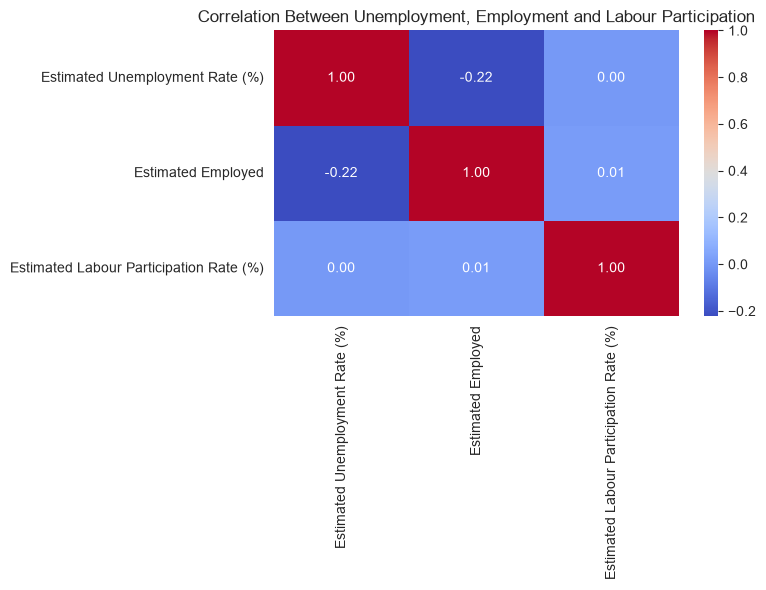

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Unemployment, Employment and Labour Participation")
plt.tight_layout()
plt.show()

In [36]:
print(
    "Observation: The heatmap shows the strength and direction of "
    "the relationships between unemployment rate, employment, and "
    "labour participation rate."
)

Observation: The heatmap shows the strength and direction of the relationships between unemployment rate, employment, and labour participation rate.


In [37]:
covid_start = pd.Timestamp("2020-03-01")

df["COVID_Period"] = np.where(
    df["Date"] < covid_start,
    "Pre-COVID",
    "Post-COVID"
)

df[["Date", "COVID_Period"]].head()

,Date,COVID_Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID


In [38]:
covid_comparison = df.groupby("COVID_Period")[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].mean()

covid_comparison

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
COVID_Period,,,
Post-COVID,17.774363,6.517203e+06,39.330049
Pre-COVID,9.509534,7.466028e+06,43.886119


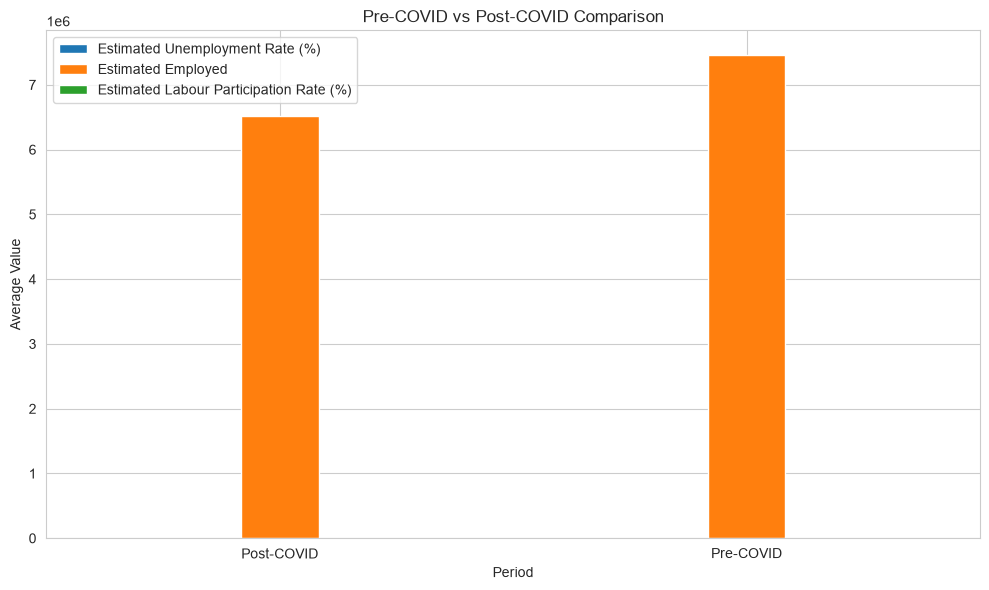

In [39]:
covid_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Pre-COVID vs Post-COVID Comparison")
plt.xlabel("Period")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
pre_covid_unemployment = covid_comparison.loc[
    "Pre-COVID",
    "Estimated Unemployment Rate (%)"
]

post_covid_unemployment = covid_comparison.loc[
    "Post-COVID",
    "Estimated Unemployment Rate (%)"
]

change = post_covid_unemployment - pre_covid_unemployment

print(f"Pre-COVID average unemployment rate: {pre_covid_unemployment:.2f}%")
print(f"Post-COVID average unemployment rate: {post_covid_unemployment:.2f}%")
print(f"Change in unemployment rate: {change:.2f} percentage points")

Pre-COVID average unemployment rate: 9.51%
Post-COVID average unemployment rate: 17.77%
Change in unemployment rate: 8.26 percentage points


In [41]:
if change > 0:
    print(
        "Observation: Average unemployment increased during the "
        "Post-COVID period compared with the Pre-COVID period."
    )
else:
    print(
        "Observation: Average unemployment decreased during the "
        "Post-COVID period compared with the Pre-COVID period."
    )

Observation: Average unemployment increased during the Post-COVID period compared with the Pre-COVID period.


In [42]:
print("""
Conclusion:

1. Unemployment rates varied across India's regions.
2. The month-wise analysis shows changes in India's unemployment rate over time.
3. The time-series analysis highlights different unemployment patterns across major regions.
4. The correlation heatmap shows relationships between unemployment,
   employment, and labour participation.
5. The pre-COVID and post-COVID comparison helps identify changes in
   unemployment during the COVID-19 period.
""")


Conclusion:

1. Unemployment rates varied across India's regions.
2. The month-wise analysis shows changes in India's unemployment rate over time.
3. The time-series analysis highlights different unemployment patterns across major regions.
4. The correlation heatmap shows relationships between unemployment,
   employment, and labour participation.
5. The pre-COVID and post-COVID comparison helps identify changes in
   unemployment during the COVID-19 period.



In [43]:
print("TASK 2 — UNEMPLOYMENT ANALYSIS CHECKLIST")
print("-" * 55)

print("✓ Dataset loaded")
print("✓ Shape inspection completed")
print("✓ Null value check completed")
print("✓ Data type conversion completed")
print("✓ Region-wise average unemployment analysis completed")
print("✓ Month-wise unemployment trend completed")
print("✓ Time-series analysis for 3 major regions completed")
print("✓ Top 10 regions by average unemployment completed")
print("✓ Correlation heatmap completed")
print("✓ Pre-COVID vs Post-COVID comparison completed")
print("✓ Observations added after visualizations")
print("✓ Final insights and conclusion completed")

TASK 2 — UNEMPLOYMENT ANALYSIS CHECKLIST
-------------------------------------------------------
✓ Dataset loaded
✓ Shape inspection completed
✓ Null value check completed
✓ Data type conversion completed
✓ Region-wise average unemployment analysis completed
✓ Month-wise unemployment trend completed
✓ Time-series analysis for 3 major regions completed
✓ Top 10 regions by average unemployment completed
✓ Correlation heatmap completed
✓ Pre-COVID vs Post-COVID comparison completed
✓ Observations added after visualizations
✓ Final insights and conclusion completed


In [44]:
df.to_csv("unemployment_india_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [45]:
print("Task 2 notebook saved successfully.")
print("Project analysis is complete.")

Task 2 notebook saved successfully.
Project analysis is complete.
